# Mutual Fund Quantitative Performance & Risk Analytics

This notebook performs a comprehensive financial and risk analytics evaluation on 40 mutual fund schemes using historical daily Net Asset Value (NAV) data from 2022 to 2026.

### Objectives:
1. **Daily Returns Analysis**: Compute and validate returns distributions for all 40 schemes.
2. **CAGR Analysis**: Compute 1-year, 3-year, and 5-year compounded annualized growth rates.
3. **Risk-Adjusted Returns**: Calculate Sharpe and Sortino Ratios using RBI Repo Rate proxy (6.5%).
4. **OLS Regression (Alpha & Beta)**: Regress fund returns on Nifty 100 returns to calculate Alpha and Beta.
5. **Maximum Drawdown**: Compute peak-to-trough declines and identify the worst drawdown date range.
6. **Fund Scorecard**: Build a composite ranking score (0-100) based on weighted risk-return metrics.
7. **Benchmark Comparison**: Plot the top 5 funds vs Nifty 50 and Nifty 100 over a 3-year horizon.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "sans-serif"

# Ensure output directories exist
os.makedirs("../reports/plots", exist_ok=True)
os.makedirs("../reports", exist_ok=True)
print("Libraries loaded and folders verified.")

Libraries loaded and folders verified.


In [2]:
# Connect to processed SQLite database
db_path = "../Data/processed/mutual_funds.db"
if not os.path.exists(db_path):
    db_path = "Data/processed/mutual_funds.db"

conn = sqlite3.connect(db_path)
print(f"Connected successfully to database: {db_path}")

# Load daily NAV joined with fund details
query = """
    SELECT fn.scheme_code, df.scheme_name, df.fund_house, df.category, df.sub_category, df.risk_grade, fn.date_key AS date, fn.nav
    FROM fact_nav fn
    JOIN dim_fund df ON fn.scheme_code = df.scheme_code
"""
df_nav_raw = pd.read_sql_query(query, conn)
df_nav_raw['date'] = pd.to_datetime(df_nav_raw['date'])
df_nav_raw = df_nav_raw.sort_values(['scheme_code', 'date']).reset_index(drop=True)

# Load expense ratios and performance metrics from fact_performance
perf_query = "SELECT scheme_code, expense_ratio FROM fact_performance"
df_perf = pd.read_sql_query(perf_query, conn)

print(f"Loaded {len(df_nav_raw)} NAV rows across {df_nav_raw['scheme_code'].nunique()} funds.")

Connected successfully to database: ../Data/processed/mutual_funds.db


Loaded 73040 NAV rows across 40 funds.


## 1. Benchmark Reconstruction & Simulation

We reconstruct the underlying market returns `market_returns` from `generate_eda_data.py` (which represents **Nifty 100**) using the identical seed `42` and date range. We then simulate the **Nifty 50** returns series using seed `50` to represent a highly correlated but distinct benchmark index.

In [3]:
import random

start_date = datetime(2022, 1, 1)
end_date = datetime(2026, 12, 31)
num_days = (end_date - start_date).days + 1
dates = [start_date + timedelta(days=i) for i in range(num_days)]

# Reconstruct Nifty 100 returns (matching generate_eda_data.py seed 42)
random.seed(42)
np.random.seed(42)
nifty100_returns = []
for d in dates:
    y, m = d.year, d.month
    if y == 2022:
        drift = -0.05 / 365
        vol = 0.01
    elif y == 2023:
        drift = 0.28 / 365
        vol = 0.008
    elif y == 2024:
        if m in [5, 6]:
            drift = -0.45 / 365
            vol = 0.015
        else:
            drift = 0.22 / 365
            vol = 0.009
    elif y == 2025:
        drift = 0.32 / 365
        vol = 0.0085
    else: # 2026
        drift = 0.06 / 365
        vol = 0.007
    nifty100_returns.append(np.random.normal(drift, vol))

# Simulate Nifty 50 returns using seed 50
random.seed(50)
np.random.seed(50)
nifty50_returns = []
for d in dates:
    y, m = d.year, d.month
    if y == 2022:
        drift = -0.04 / 365
        vol = 0.0095
    elif y == 2023:
        drift = 0.26 / 365
        vol = 0.0075
    elif y == 2024:
        if m in [5, 6]:
            drift = -0.40 / 365
            vol = 0.014
        else:
            drift = 0.20 / 365
            vol = 0.0085
    elif y == 2025:
        drift = 0.30 / 365
        vol = 0.008
    else: # 2026
        drift = 0.05 / 365
        vol = 0.0065
    nifty50_returns.append(np.random.normal(drift, vol))

# Create benchmark returns DataFrames
df_benchmarks = pd.DataFrame({
    'date': dates,
    'nifty100_return': nifty100_returns,
    'nifty50_return': nifty50_returns
})
df_benchmarks['nifty100_nav'] = np.cumprod(1 + np.array(nifty100_returns)) * 10000.0
df_benchmarks['nifty50_nav'] = np.cumprod(1 + np.array(nifty50_returns)) * 10000.0

print("Benchmark returns and NAV indices successfully constructed.")

Benchmark returns and NAV indices successfully constructed.


## 2. Daily Returns Computation & Validation

Daily returns are computed as:
$$daily\_return_t = \frac{NAV_t}{NAV_{t-1}} - 1$$

In [4]:
# Pivot NAV data to get dates as index and scheme codes as columns
df_pivot = df_nav_raw.pivot(index='date', columns='scheme_code', values='nav')
df_pivot = df_pivot.ffill()

# Compute daily returns
df_returns = df_pivot.pct_change()

# Map scheme codes to names for columns
fund_name_map = dict(zip(df_nav_raw['scheme_code'], df_nav_raw['scheme_name']))
df_returns_named = df_returns.rename(columns=fund_name_map)

print(f"Daily returns computed. Shape: {df_returns.shape}")

Daily returns computed. Shape: (1826, 40)


### Distribution Validation

We inspect the daily returns distribution using descriptive statistics (mean, std, min, max, skewness, and kurtosis) and visually plot return distributions to verify they look reasonable and are centered close to 0 with standard financial fat-tailed profiles.

Daily Returns Summary Statistics (First 10 Schemes):
 scheme_code                                                           scheme_name     mean      std       min      max     skew  kurtosis
      118632 Nippon India Large Cap Fund - Direct Plan Growth Plan - Growth Option 0.000853 0.008059 -0.029258 0.032020 0.125582  0.231251
      119062                 HDFC Hybrid Equity Fund - Growth Option - Direct Plan 0.000629 0.005959 -0.023467 0.026617 0.070481  0.501592
      119092                  HDFC Money Market Fund - Growth Option - Direct Plan 0.000153 0.001338 -0.004028 0.005393 0.063776 -0.004849
      119551        Aditya Birla Sun Life Banking & PSU Debt Fund  - DIRECT - IDCW 0.000176 0.001580 -0.006107 0.006334 0.068336  0.231443
      119777                   Kotak Multi Asset Omni FOF - Direct Growth - Direct 0.000289 0.002086 -0.006376 0.008030 0.085749  0.292512
      120101                              SBI Bluechip Fund - Direct Plan - Growth 0.000983 0.008994 -0.031520 0.

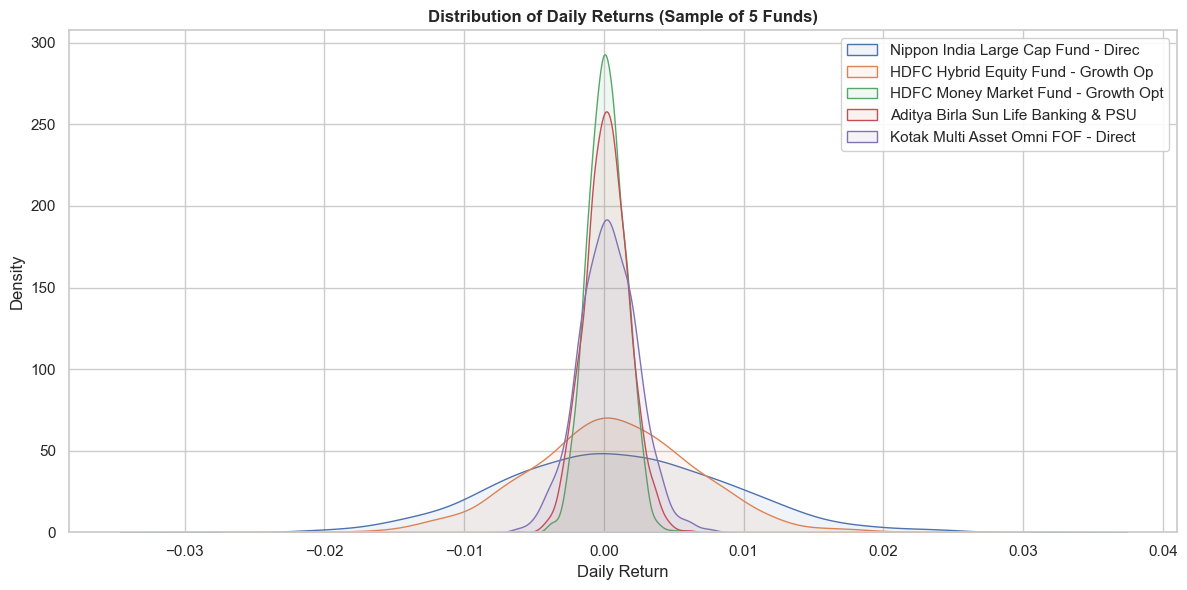

In [5]:
# Validate return distribution with summary statistics
returns_summary = []
for code in df_returns.columns:
    ret_series = df_returns[code].dropna()
    returns_summary.append({
        'scheme_code': code,
        'scheme_name': fund_name_map[code],
        'mean': ret_series.mean(),
        'std': ret_series.std(),
        'min': ret_series.min(),
        'max': ret_series.max(),
        'skew': ret_series.skew(),
        'kurtosis': ret_series.kurtosis()
    })
df_returns_summary = pd.DataFrame(returns_summary)

# Display a subset of summary statistics
print("Daily Returns Summary Statistics (First 10 Schemes):")
print(df_returns_summary.head(10).to_string(index=False))

# Plot returns distribution for a sample of 5 funds
plt.figure(figsize=(12, 6))
sample_schemes = list(df_pivot.columns[:5])
for code in sample_schemes:
    sns.kdeplot(df_returns[code].dropna(), label=fund_name_map[code][:35], fill=True, alpha=0.08)
plt.title("Distribution of Daily Returns (Sample of 5 Funds)", fontweight='bold', fontsize=12)
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.savefig("../reports/plots/returns_distribution.png", dpi=150)
plt.show()

## 3. Compounded Annual Growth Rate (CAGR) Analysis

CAGR is calculated as:
$$CAGR = \left(\frac{NAV_{end}}{NAV_{start}}\right)^{\frac{1}{n}} - 1$$

We compute CAGR for three specific horizons:
- **1 Year**: 2025-12-31 to 2026-12-31 ($n = 1.0$)
- **3 Year**: 2023-12-31 to 2026-12-31 ($n = 3.0$)
- **5 Year**: 2022-01-01 to 2026-12-31 ($n = 1825 / 365.25 \approx 5.0$)

In [6]:
cagr_data = []
for code in df_pivot.columns:
    navs = df_pivot[code]
    
    # 1yr CAGR
    nav_end_1y = navs.loc['2026-12-31']
    nav_start_1y = navs.loc['2025-12-31']
    cagr_1y = (nav_end_1y / nav_start_1y) ** (1.0) - 1
    
    # 3yr CAGR
    nav_end_3y = navs.loc['2026-12-31']
    nav_start_3y = navs.loc['2023-12-31']
    cagr_3y = (nav_end_3y / nav_start_3y) ** (1.0 / 3.0) - 1
    
    # 5yr CAGR (first day 2022-01-01 to 2026-12-31)
    nav_end_5y = navs.loc['2026-12-31']
    nav_start_5y = navs.loc['2022-01-01']
    days_5y = (datetime(2026,12,31) - datetime(2022,1,1)).days
    years_5y = days_5y / 365.25
    cagr_5y = (nav_end_5y / nav_start_5y) ** (1.0 / years_5y) - 1
    
    cagr_data.append({
        'scheme_code': code,
        'scheme_name': fund_name_map[code],
        'cagr_1yr': cagr_1y,
        'cagr_3yr': cagr_3y,
        'cagr_5yr': cagr_5y
    })

df_cagr = pd.DataFrame(cagr_data)
print("Compounded Annualized Growth Rates (First 10 Schemes):")
print(df_cagr.head(10).to_string(index=False))

Compounded Annualized Growth Rates (First 10 Schemes):
 scheme_code                                                           scheme_name  cagr_1yr  cagr_3yr  cagr_5yr
      118632 Nippon India Large Cap Fund - Direct Plan Growth Plan - Growth Option  0.184005  0.547584  0.349418
      119062                 HDFC Hybrid Equity Fund - Growth Option - Direct Plan  0.107491  0.373247  0.250135
      119092                  HDFC Money Market Fund - Growth Option - Direct Plan  0.026066  0.074939  0.057080
      119551        Aditya Birla Sun Life Banking & PSU Debt Fund  - DIRECT - IDCW  0.036209  0.097855  0.065861
      119777                   Kotak Multi Asset Omni FOF - Direct Growth - Direct  0.065714  0.143375  0.110422
      120101                              SBI Bluechip Fund - Direct Plan - Growth  0.242801  0.631647  0.410711
      120102                                SBI Contra Fund - Direct Plan - Growth  0.193207  0.692747  0.402023
      120103                         SBI 

## 4. Sharpe and Sortino Ratios

Ratios evaluate risk-adjusted performance using an annual risk-free rate proxy of $R_f = 6.5\%$ (daily $R_f = 6.5\% / 252$). Both ratios are annualized using $\sqrt{252}$:

- **Sharpe Ratio**:
$$Sharpe = \frac{R_p - R_f}{Std(R_p)} \times \sqrt{252}$$

- **Sortino Ratio**:
$$Sortino = \frac{R_p - R_f}{DownsideStd(R_p)} \times \sqrt{252}$$
where downside volatility is computed on negative return days only ($R_p < 0$).

In [7]:
rf_annual = 0.065
rf_daily = rf_annual / 252

ratios_data = []
for code in df_returns.columns:
    ret = df_returns[code].dropna()
    mean_ret = ret.mean()
    std_ret = ret.std()
    
    # Sharpe Ratio
    sharpe = (mean_ret - rf_daily) / std_ret * np.sqrt(252) if std_ret > 0 else 0
    
    # Downside Volatility
    downside_ret = ret[ret < 0]
    downside_std = downside_ret.std()
    
    # Sortino Ratio
    sortino = (mean_ret - rf_daily) / downside_std * np.sqrt(252) if downside_std > 0 else 0
    
    ratios_data.append({
        'scheme_code': code,
        'scheme_name': fund_name_map[code],
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino
    })

df_ratios = pd.DataFrame(ratios_data)
print("Risk-Adjusted Ratios (First 10 Schemes):")
print(df_ratios.head(10).to_string(index=False))

Risk-Adjusted Ratios (First 10 Schemes):
 scheme_code                                                           scheme_name  sharpe_ratio  sortino_ratio
      118632 Nippon India Large Cap Fund - Direct Plan Growth Plan - Growth Option      1.172493       2.074369
      119062                 HDFC Hybrid Equity Fund - Growth Option - Direct Plan      0.988887       1.653090
      119092                  HDFC Money Market Fund - Growth Option - Direct Plan     -1.246380      -2.192956
      119551        Aditya Birla Sun Life Banking & PSU Debt Fund  - DIRECT - IDCW     -0.824233      -1.406598
      119777                   Kotak Multi Asset Omni FOF - Direct Growth - Direct      0.236244       0.409728
      120101                              SBI Bluechip Fund - Direct Plan - Growth      1.279514       2.210994
      120102                                SBI Contra Fund - Direct Plan - Growth      1.133079       1.950688
      120103                         SBI Magnum Midcap Fund - D

## 5. Alpha, Beta, and Tracking Error Analysis

We regress daily fund returns on daily Nifty 100 returns using Ordinary Least Squares (OLS) regression (`scipy.stats.linregress`):
- **Beta ($\beta$)**: Slope of regression.
- **Alpha ($\alpha$)**: Intercept annualized, $\alpha = intercept \times 252$.
- **Tracking Error**: Annualized standard deviation of active returns:
$$Tracking\_Error = Std(R_{fund} - R_{benchmark}) \times \sqrt{252}$$

We also calculate tracking error relative to both benchmarks for robust analysis.

In [8]:
nifty100_ret_series = df_benchmarks.set_index('date')['nifty100_return']
nifty50_ret_series = df_benchmarks.set_index('date')['nifty50_return']

alpha_beta_data = []
for code in df_returns.columns:
    fund_ret = df_returns[code].dropna()
    # Align dates
    aligned = pd.concat([fund_ret, nifty100_ret_series, nifty50_ret_series], axis=1, join='inner').dropna()
    
    fund_aligned = aligned.iloc[:, 0]
    n100_aligned = aligned.iloc[:, 1]
    n50_aligned = aligned.iloc[:, 2]
    
    # Regression against Nifty 100
    slope, intercept, r_value, p_value, std_err = stats.linregress(n100_aligned, fund_aligned)
    beta = slope
    alpha = intercept * 252
    
    # Tracking Errors
    te_n100 = (fund_aligned - n100_aligned).std() * np.sqrt(252)
    te_n50 = (fund_aligned - n50_aligned).std() * np.sqrt(252)
    
    alpha_beta_data.append({
        'scheme_code': code,
        'scheme_name': fund_name_map[code],
        'alpha': alpha,
        'beta': beta,
        'tracking_error_nifty100': te_n100,
        'tracking_error_nifty50': te_n50
    })

df_alpha_beta = pd.DataFrame(alpha_beta_data)
print("Alpha, Beta & Tracking Error (First 10 Schemes):")
print(df_alpha_beta.head(10).to_string(index=False))

# Export alpha_beta.csv file
df_alpha_beta.to_csv("../reports/alpha_beta.csv", index=False)
df_alpha_beta.to_csv("../alpha_beta.csv", index=False) # save in root too
print("Saved alpha_beta.csv successfully.")

Alpha, Beta & Tracking Error (First 10 Schemes):
 scheme_code                                                           scheme_name     alpha     beta  tracking_error_nifty100  tracking_error_nifty50
      118632 Nippon India Large Cap Fund - Direct Plan Growth Plan - Growth Option  0.033605 0.858801                 0.052281                0.183550
      119062                 HDFC Hybrid Equity Fund - Growth Option - Direct Plan  0.022370 0.644673                 0.058740                0.162232
      119092                  HDFC Money Market Fund - Growth Option - Direct Plan  0.016020 0.106553                 0.124110                0.134981
      119551        Aditya Birla Sun Life Banking & PSU Debt Fund  - DIRECT - IDCW  0.014299 0.142145                 0.119284                0.135589
      119777                   Kotak Multi Asset Omni FOF - Direct Growth - Direct  0.028493 0.209861                 0.110102                0.137082
      120101                              SBI

## 6. Maximum Drawdown & Date Ranges

Maximum drawdown is calculated as:
$$Drawdown_t = \frac{NAV_t}{RunningMax(NAV)_t} - 1$$
$$MaxDrawdown = \min(Drawdown)$$

For each scheme, we identify the peak date (the last date running max was updated before the drawdown valley) and the trough date (the date of the worst drawdown valley) to establish the worst drawdown date range.

In [9]:
mdd_data = []
for code in df_pivot.columns:
    navs = df_pivot[code]
    running_max = navs.cummax()
    drawdowns = navs / running_max - 1
    max_dd = drawdowns.min()
    
    trough_date = drawdowns.idxmin()
    peak_date = navs.loc[:trough_date].idxmax()
    
    mdd_data.append({
        'scheme_code': code,
        'scheme_name': fund_name_map[code],
        'max_drawdown': max_dd,
        'drawdown_peak_date': peak_date.strftime('%Y-%m-%d'),
        'drawdown_trough_date': trough_date.strftime('%Y-%m-%d')
    })

df_mdd = pd.DataFrame(mdd_data)
print("Maximum Drawdowns and Peak-to-Trough Date Ranges (First 10 Schemes):")
print(df_mdd.head(10).to_string(index=False))

Maximum Drawdowns and Peak-to-Trough Date Ranges (First 10 Schemes):
 scheme_code                                                           scheme_name  max_drawdown drawdown_peak_date drawdown_trough_date
      118632 Nippon India Large Cap Fund - Direct Plan Growth Plan - Growth Option     -0.129415         2022-01-08           2022-06-05
      119062                 HDFC Hybrid Equity Fund - Growth Option - Direct Plan     -0.143394         2022-01-13           2022-05-28
      119092                  HDFC Money Market Fund - Growth Option - Direct Plan     -0.025329         2022-01-10           2022-06-05
      119551        Aditya Birla Sun Life Banking & PSU Debt Fund  - DIRECT - IDCW     -0.027693         2022-03-15           2022-06-05
      119777                   Kotak Multi Asset Omni FOF - Direct Growth - Direct     -0.030568         2022-01-13           2022-02-16
      120101                              SBI Bluechip Fund - Direct Plan - Growth     -0.139483         2022

## 7. Fund Scorecard Compilation

We construct a composite scorecard index $(0-100)$ to rank all 40 schemes based on the following weighted ranks:
- **30%** weight on **3-year return rank**
- **25%** weight on **Sharpe ratio rank**
- **20%** weight on **Alpha rank**
- **15%** weight on **Expense Ratio rank (inverse)** (lower is better)
- **10%** weight on **Maximum Drawdown rank (inverse)** (less negative/higher is better)

All ranks are percentile-normalized: $R_{metric} = \frac{rank - 1}{N - 1} \times 100$ so the worst fund gets $0$ and the best gets $100$.

In [10]:
# Compile all metrics into one DataFrame
df_master_metrics = df_cagr.merge(df_ratios, on=['scheme_code', 'scheme_name'])
df_master_metrics = df_master_metrics.merge(df_alpha_beta, on=['scheme_code', 'scheme_name'])
df_master_metrics = df_master_metrics.merge(df_mdd, on=['scheme_code', 'scheme_name'])
df_master_metrics = df_master_metrics.merge(df_perf[['scheme_code', 'expense_ratio']], on='scheme_code')

# Calculate ranks (1 to 40)
df_master_metrics['rank_3yr'] = df_master_metrics['cagr_3yr'].rank(ascending=True)
df_master_metrics['rank_sharpe'] = df_master_metrics['sharpe_ratio'].rank(ascending=True)
df_master_metrics['rank_alpha'] = df_master_metrics['alpha'].rank(ascending=True)
df_master_metrics['rank_expense'] = df_master_metrics['expense_ratio'].rank(ascending=False) # Lower expense is better
df_master_metrics['rank_max_dd'] = df_master_metrics['max_drawdown'].rank(ascending=True) # Less negative is better

# Normalize ranks to 0-100 scale
N = len(df_master_metrics)
for col in ['rank_3yr', 'rank_sharpe', 'rank_alpha', 'rank_expense', 'rank_max_dd']:
    df_master_metrics[f'{col}_norm'] = (df_master_metrics[col] - 1) / (N - 1) * 100

# Compute composite score
df_master_metrics['scorecard_score'] = (
    0.30 * df_master_metrics['rank_3yr_norm'] +
    0.25 * df_master_metrics['rank_sharpe_norm'] +
    0.20 * df_master_metrics['rank_alpha_norm'] +
    0.15 * df_master_metrics['rank_expense_norm'] +
    0.10 * df_master_metrics['rank_max_dd_norm']
)

# Sort and assign overall rank
df_master_metrics = df_master_metrics.sort_values(by='scorecard_score', ascending=False).reset_index(drop=True)
df_master_metrics['overall_rank'] = df_master_metrics.index + 1

# Select scorecard report columns
scorecard_cols = [
    'overall_rank', 'scheme_name', 'scheme_code', 'scorecard_score',
    'cagr_3yr', 'sharpe_ratio', 'alpha', 'expense_ratio', 'max_drawdown',
    'drawdown_peak_date', 'drawdown_trough_date'
]
df_scorecard_report = df_master_metrics[scorecard_cols]

print("Top 10 Schemes by Composite Scorecard Score:")
print(df_scorecard_report.head(10).to_string(index=False))

# Export scorecard to CSV
df_scorecard_report.to_csv("../reports/fund_scorecard.csv", index=False)
df_scorecard_report.to_csv("../fund_scorecard.csv", index=False) # save in root too
print("Saved fund_scorecard.csv successfully.")

Top 10 Schemes by Composite Scorecard Score:


 overall_rank                                            scheme_name  scheme_code  scorecard_score  cagr_3yr  sharpe_ratio    alpha  expense_ratio  max_drawdown drawdown_peak_date drawdown_trough_date
            1  ICICI Prudential Smallcap Fund - Direct Plan - Growth       120114        83.205128  0.894319      1.370663 0.059929           1.39     -0.252310         2022-01-10           2022-04-21
            2    ICICI Prudential Midcap Fund - Direct Plan - Growth       120113        82.435897  0.798425      1.420457 0.067060           1.30     -0.211675         2022-01-08           2022-04-14
            3               SBI Bluechip Fund - Direct Plan - Growth       120101        77.435897  0.631647      1.279514 0.041324           0.10     -0.139483         2022-01-10           2022-04-21
            4 HDFC Mid-Cap Opportunities Fund - Direct Plan - Growth       120108        76.282051  0.801236      1.285183 0.040322           1.43     -0.174609         2022-01-10           2022-

## 8. Benchmark Comparison Chart (3-Year Timeline)

We select the **top 5 funds** based on our scorecard composite index and plot their cumulative performance (Growth of 10,000 INR starting on `2024-01-01`) against both **Nifty 50** and **Nifty 100** benchmarks through `2026-12-31`.

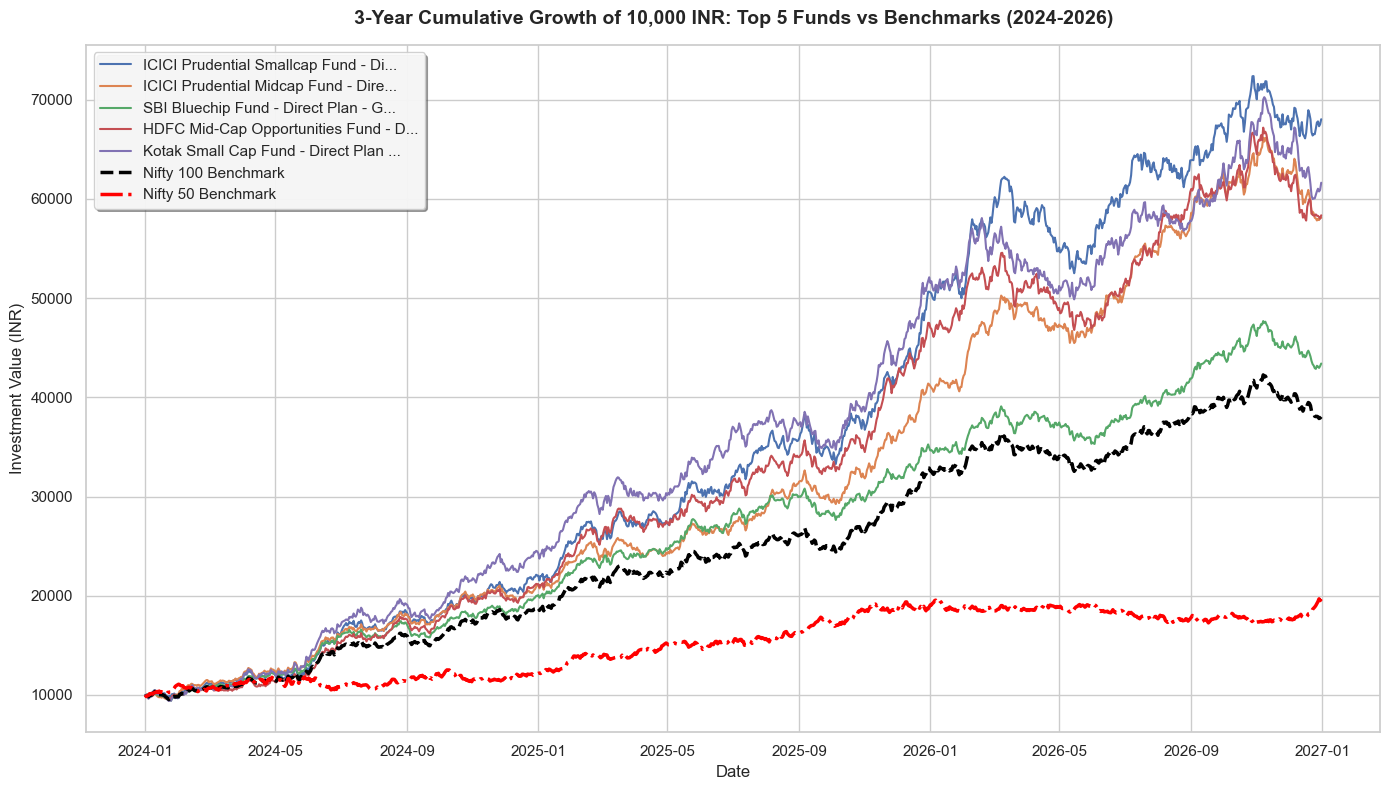

Benchmark comparison chart generated and saved successfully.


In [11]:
# Filter top 5 schemes
top_5_schemes = list(df_scorecard_report.head(5)['scheme_code'])

start_3y = '2024-01-01'
df_nav_3y = df_pivot[top_5_schemes].loc[start_3y:'2026-12-31']

# Normalize growth of 10k
df_growth_3y = (df_nav_3y / df_nav_3y.iloc[0]) * 10000.0

# Add benchmark series standardized to 2024-01-01
df_benchmarks_3y = df_benchmarks.set_index('date').loc[start_3y:'2026-12-31']
bench_growth_100 = (df_benchmarks_3y['nifty100_nav'] / df_benchmarks_3y['nifty100_nav'].iloc[0]) * 10000.0
bench_growth_50 = (df_benchmarks_3y['nifty50_nav'] / df_benchmarks_3y['nifty50_nav'].iloc[0]) * 10000.0

# Plotting
plt.figure(figsize=(14, 8))
for code in top_5_schemes:
    plt.plot(df_growth_3y.index, df_growth_3y[code], label=f"{fund_name_map[code][:35]}...", linewidth=1.5)

# Plot benchmarks with distinct styling
plt.plot(bench_growth_100.index, bench_growth_100, label="Nifty 100 Benchmark", color='black', linestyle='--', linewidth=2.5)
plt.plot(bench_growth_50.index, bench_growth_50, label="Nifty 50 Benchmark", color='red', linestyle='-.', linewidth=2.5)

plt.title("3-Year Cumulative Growth of 10,000 INR: Top 5 Funds vs Benchmarks (2024-2026)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Investment Value (INR)", fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True, facecolor='white', framealpha=0.9)
plt.tight_layout()

# Save chart PNG
plt.savefig("../reports/plots/benchmark_comparison.png", dpi=300)
plt.savefig("../benchmark_comparison.png", dpi=300) # save in root too
plt.show()
print("Benchmark comparison chart generated and saved successfully.")

In [12]:
conn.close()
print("Database connection closed.")

Database connection closed.
